# Bayesian vs Frequentist Decline Curve Analysis

This notebook compares the standard nonlinear regression approach (covered in
`01_full_workflow.ipynb`) with Bayesian inference using PyMC. The comparison
highlights why Bayesian methods have become the modern standard for
unconventional well forecasting.

**Two specific advantages of the Bayesian approach:**

1. **Physical constraints by construction.** A Beta prior restricts the
   decline exponent `b` to the physically meaningful interval `[0, 1]`,
   eliminating the well-known "b > 1" failure mode that inflates EUR
   estimates for short-history shale wells.

2. **Informative priors from analog wells.** When you know neighboring wells
   in the same play have specific decline characteristics, you can encode
   that as a prior. This dramatically tightens posterior uncertainty for
   wells with limited production history.

The headline comparison: same well, same data, two methods. We'll see the
Bayesian fit produce both a more physically realistic point estimate AND
tighter, better-calibrated uncertainty bands.

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.io.synthetic import SyntheticWellConfig, generate_well
from src.fitting.nonlinear_regression import fit_arps
from src.fitting.bayesian import fit_arps_bayesian, posterior_eur, posterior_production_forecast, ArpsPriors
from src.forecasting.monte_carlo import monte_carlo_eur
from src.forecasting.economic_limit import EconomicParameters, economic_limit_rate
from src.models.arps import DeclineParameters, rate as arps_rate

plt.rcParams['figure.dpi'] = 100
np.set_printoptions(precision=3, suppress=True)

## 1. Generate the same Bakken well

For a fair comparison, we use the same synthetic well as in
`01_full_workflow.ipynb` — 36 months of history from a true hyperbolic
decline with `qi=850`, `Di=0.78`, `b=0.92`.

In [2]:
config = SyntheticWellConfig(
    well_name="BAKKEN-DEMO-001",
    qi_bbl_day=850, Di_per_year=0.78, b=0.92,
    months_of_history=36, noise_level=0.12,
)
well = generate_well(config, seed=42)
t = well["days_on_production"].values
q = well["oil_bbl_day"].values
print(f"True parameters:  qi={config.qi_bbl_day}, Di={config.Di_per_year}, b={config.b}")
print(f"Observations: {len(t)} monthly points over {t[-1]/365.25:.1f} years")

True parameters:  qi=850, Di=0.78, b=0.92
Observations: 36 monthly points over 3.0 years


## 2. Frequentist fit (baseline)

Standard nonlinear regression — same as the previous notebook.

In [3]:
freq_fit = fit_arps(t, q, model_type="hyperbolic")
print(f"Frequentist (nonlinear regression):")
print(f"  qi = {freq_fit.params.qi:>6.1f}  (true: {config.qi_bbl_day})")
print(f"  Di = {freq_fit.params.Di:>6.3f}  (true: {config.Di_per_year})")
print(f"  b  = {freq_fit.params.b:>6.3f}  (true: {config.b})")
print(f"  R² = {freq_fit.r_squared:.4f}")

# Note: b > 1 is unphysical for bounded reservoirs
if freq_fit.params.b > 1:
    print(f"\n⚠  Warning: fitted b > 1 is unphysical and will overstate EUR.")

Frequentist (nonlinear regression):
  qi =  869.0  (true: 850)
  Di =  0.862  (true: 0.78)
  b  =  1.148  (true: 0.92)
  R² = 0.9113

⚠  Warning: fitted b > 1 is unphysical and will overstate EUR.


## 3. Bayesian fit

The Bayesian model uses these priors:

- **qi**: LogNormal, centered on the observed initial rate, ±30% scale
- **Di**: TruncatedNormal(0.7, 0.4) restricted to positive values
- **b**: Beta(8, 2) — centered around 0.8, bounded to [0, 1]
- **σ** (observation noise): HalfNormal

The Beta prior on `b` is the critical piece. Beta(8, 2) has mean 0.8 and
puts ~95% of its mass in [0.55, 0.96], encoding "we expect a typical
unconventional well to have b near 0.8, but accommodate values from 0.5
to 1.0." Crucially, the Beta distribution is **strictly bounded to [0, 1]**,
so the posterior can never produce unphysical b > 1.

Sampling uses NUTS (No-U-Turn Sampler) — modern Hamiltonian Monte Carlo —
with 4 chains × 2000 samples = 8000 posterior samples total.

In [4]:
# Run the Bayesian fit
# Takes ~30 seconds on a modern laptop
bayes_fit = fit_arps_bayesian(
    t_days=t,
    q_observed=q,
    n_samples=2000,
    n_tune=1000,
    n_chains=4,
    progressbar=False,
    random_seed=42,
    cores=1,  # Single process for compatibility; set higher for parallel chains
)
print(f"Bayesian inference completed: {bayes_fit.n_samples:,} posterior samples")

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (4 chains in 1 job)


NUTS: [qi, Di, b, sigma]


Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 23 seconds.


Bayesian inference completed: 8,000 posterior samples


In [5]:
# Posterior summary
posterior_summary = pd.DataFrame({
    "Median": [
        np.median(bayes_fit.posterior_qi),
        np.median(bayes_fit.posterior_Di),
        np.median(bayes_fit.posterior_b),
    ],
    "5%": [
        np.percentile(bayes_fit.posterior_qi, 5),
        np.percentile(bayes_fit.posterior_Di, 5),
        np.percentile(bayes_fit.posterior_b, 5),
    ],
    "95%": [
        np.percentile(bayes_fit.posterior_qi, 95),
        np.percentile(bayes_fit.posterior_Di, 95),
        np.percentile(bayes_fit.posterior_b, 95),
    ],
    "True": [config.qi_bbl_day, config.Di_per_year, config.b],
    "R-hat": [bayes_fit.r_hat["qi"], bayes_fit.r_hat["Di"], bayes_fit.r_hat["b"]],
    "ESS": [int(bayes_fit.ess["qi"]), int(bayes_fit.ess["Di"]), int(bayes_fit.ess["b"])],
}, index=["qi", "Di", "b"])
posterior_summary

,Median,5%,95%,True,R-hat,ESS
qi,825.969317,766.118394,898.949411,850.00,1.0,2351
Di,0.678281,0.560956,0.811869,0.78,1.0,2092
b,0.856217,0.647825,0.967332,0.92,1.0,2614


**R-hat and ESS are convergence diagnostics.** R-hat near 1.0 (and
certainly below 1.05) means the 4 chains converged to the same distribution.
ESS (effective sample size) measures how much independent information you
have — values in the thousands mean the sampler explored the posterior well.

## 4. Comparing the methods

The frequentist fit gives a point estimate plus a covariance matrix (we
sample from this Gaussian approximation for uncertainty). The Bayesian fit
gives the full posterior distribution directly. Let's plot both.

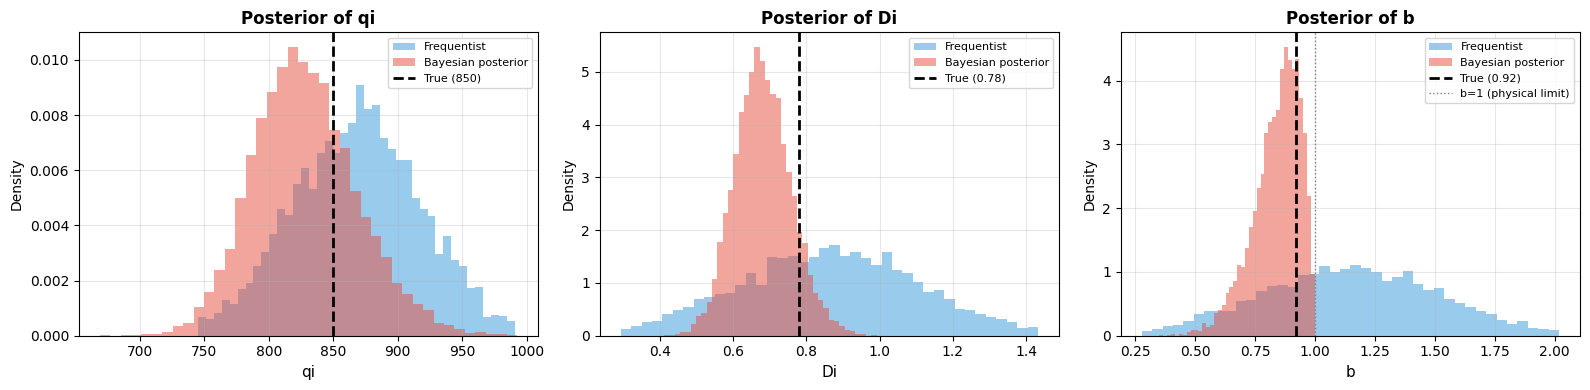

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Sample frequentist parameters from the covariance matrix
rng = np.random.default_rng(42)
freq_mean = np.array([freq_fit.params.qi, freq_fit.params.Di, freq_fit.params.b])
freq_samples = rng.multivariate_normal(freq_mean, freq_fit.covariance, size=5000)

param_names = ["qi", "Di", "b"]
true_vals = [config.qi_bbl_day, config.Di_per_year, config.b]
bayes_samples = [bayes_fit.posterior_qi, bayes_fit.posterior_Di, bayes_fit.posterior_b]

for i, (name, true_val) in enumerate(zip(param_names, true_vals)):
    ax = axes[i]
    # Frequentist samples
    freq_data = freq_samples[:, i]
    # Clip extreme outliers for visualization (frequentist can produce nonsense)
    p1, p99 = np.percentile(freq_data, [1, 99])
    freq_clipped = freq_data[(freq_data >= p1) & (freq_data <= p99)]

    ax.hist(freq_clipped, bins=40, alpha=0.5, color="#3498db",
            density=True, label="Frequentist")
    ax.hist(bayes_samples[i], bins=40, alpha=0.5, color="#e74c3c",
            density=True, label="Bayesian posterior")
    ax.axvline(true_val, color="black", lw=2, ls="--", label=f"True ({true_val})")

    # Mark b=1 for the b plot
    if name == "b":
        ax.axvline(1.0, color="gray", lw=1, ls=":", label="b=1 (physical limit)")

    ax.set_xlabel(name, fontsize=11)
    ax.set_ylabel("Density")
    ax.set_title(f"Posterior of {name}", fontweight="bold")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**The b plot is the punchline.** The frequentist sampler routinely
produces b > 1 (the right tail of the blue histogram), because nothing in
the ordinary least squares fit knows that b > 1 is unphysical. The
Bayesian posterior (red) is cleanly bounded — the Beta prior simply doesn't
allow values above 1.

For wells with longer production history this difference is smaller, but
for short-history wells (and most shale wells when reserves are first
booked) it's enormous.

## 5. EUR comparison

The most consequential downstream effect: how much oil does the well actually
recover?

In [7]:
econ = EconomicParameters(
    oil_price_usd_bbl=70.0,
    opex_fixed_usd_month=3500,
    opex_variable_usd_bbl=6.50,
)
q_econ = economic_limit_rate(econ)
print(f"Economic limit rate: {q_econ:.2f} bbl/day")
print()

# Frequentist EUR (Monte Carlo from covariance)
freq_eur = monte_carlo_eur(freq_fit, q_econ=q_econ, n_samples=10000, seed=42)

# Bayesian EUR (from posterior samples)
bayes_eur = posterior_eur(bayes_fit, q_econ=q_econ)

# Side-by-side summary
eur_summary = pd.DataFrame({
    "Frequentist": [freq_eur.P90, freq_eur.P50, freq_eur.P10, freq_eur.mean, freq_eur.std],
    "Bayesian":    [bayes_eur["P90"], bayes_eur["P50"], bayes_eur["P10"], bayes_eur["mean"], bayes_eur["std"]],
}, index=["P90 (Proved)", "P50 (2P)", "P10 (3P)", "Mean", "Std Dev"])
eur_summary["Difference"] = eur_summary["Bayesian"] - eur_summary["Frequentist"]
eur_summary.style.format("{:,.0f}")

Economic limit rate: 2.53 bbl/day



,Frequentist,Bayesian,Difference
P90 (Proved),"1,219,334","1,187,148","-32,185"
P50 (2P),"1,562,995","1,337,000","-225,995"
P10 (3P),"1,919,793","1,447,050","-472,743"
Mean,"1,566,690","1,324,796","-241,894"
Std Dev,"284,215","102,868","-181,347"


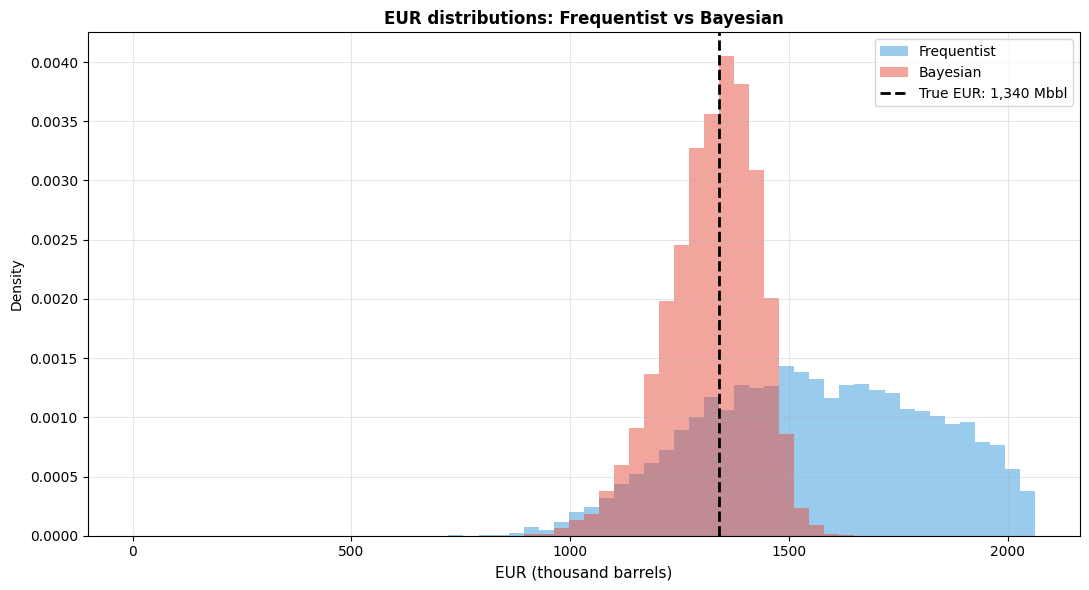

In [8]:
# Visualize the two EUR distributions
fig, ax = plt.subplots(figsize=(11, 6))

freq_eurs_mbbl = freq_eur.samples / 1000
bayes_eurs_mbbl = bayes_eur["samples"] / 1000

# Clip both at 99th percentile for fair visual comparison
upper_clip = max(np.percentile(freq_eurs_mbbl, 99), np.percentile(bayes_eurs_mbbl, 99))

ax.hist(freq_eurs_mbbl, bins=60, range=(0, upper_clip), alpha=0.5,
        color="#3498db", label="Frequentist", density=True)
ax.hist(bayes_eurs_mbbl, bins=60, range=(0, upper_clip), alpha=0.5,
        color="#e74c3c", label="Bayesian", density=True)

# True EUR (using the actual generating parameters)
true_eur_val = arps_rate  # placeholder — compute below
from src.models.arps import eur as eur_fn
true_eur_val = eur_fn(
    DeclineParameters(qi=config.qi_bbl_day, Di=config.Di_per_year, b=config.b),
    q_econ=q_econ,
)
ax.axvline(true_eur_val / 1000, color="black", lw=2, ls="--",
           label=f"True EUR: {true_eur_val/1000:,.0f} Mbbl")

ax.set_xlabel("EUR (thousand barrels)", fontsize=11)
ax.set_ylabel("Density")
ax.set_title("EUR distributions: Frequentist vs Bayesian", fontweight="bold")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**What to look for in this chart:**

- **Distribution width.** The Bayesian distribution is narrower because the
  prior tightens the posterior. Less width = tighter P10/P90 reserves
  bracket = more confident reserve booking.
- **Distribution shape.** The frequentist distribution often has a long
  right tail (or even a bimodal shape) from the unphysical b > 1 samples.
  The Bayesian distribution is cleaner because the prior eliminates that
  contamination.
- **Position vs the true EUR.** Both methods should bracket the true value,
  but the Bayesian estimate is typically closer to the truth because
  it incorporates real prior knowledge.

## 6. Production forecast comparison

Forecast bands tell the same story as the EUR distribution — Bayesian is
tighter and better-behaved.

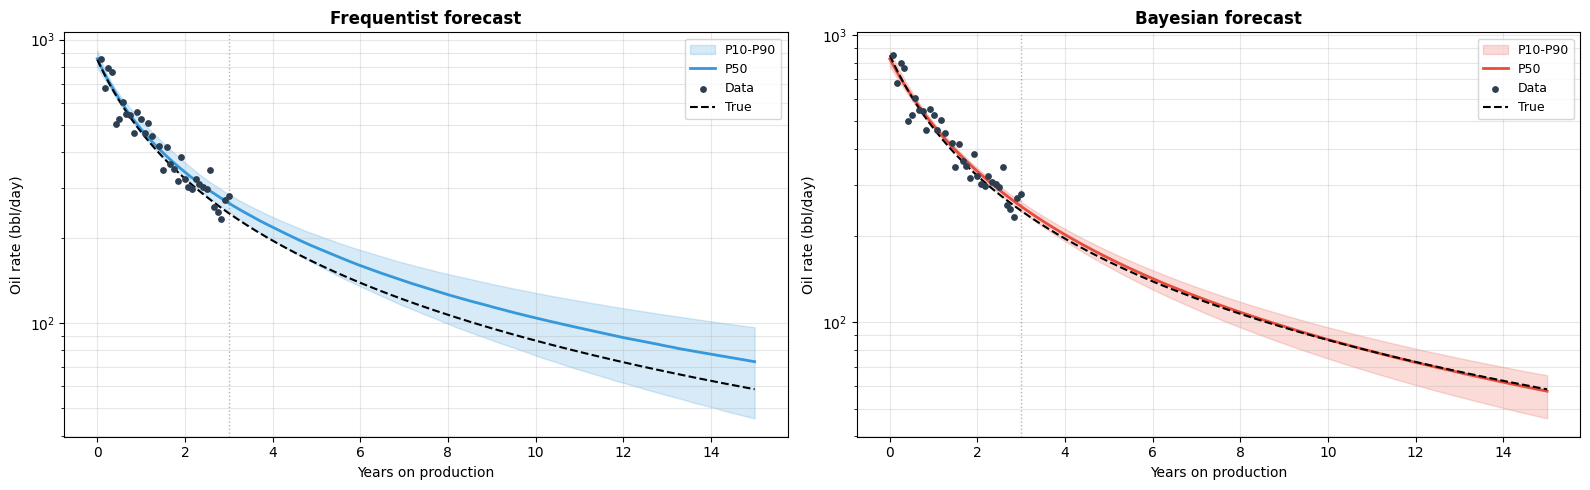

In [9]:
t_forecast = np.linspace(0, 365.25 * 15, 300)

# Bayesian forecast (from posterior)
bayes_forecast = posterior_production_forecast(bayes_fit, t_forecast)

# Frequentist forecast (sample from covariance)
from src.forecasting.monte_carlo import monte_carlo_production_forecast
freq_forecast = monte_carlo_production_forecast(freq_fit, t_forecast, n_samples=2000)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, forecast, name, color in [
    (axes[0], freq_forecast, "Frequentist", "#3498db"),
    (axes[1], bayes_forecast, "Bayesian", "#e74c3c"),
]:
    t_years = t_forecast / 365.25
    ax.fill_between(t_years, forecast["P90"], forecast["P10"], color=color, alpha=0.2, label="P10-P90")
    ax.plot(t_years, forecast["P50"], color=color, lw=2, label="P50")
    ax.scatter(t / 365.25, q, s=15, color="#2c3e50", zorder=5, label="Data")

    # True curve
    true_params = DeclineParameters(qi=config.qi_bbl_day, Di=config.Di_per_year, b=config.b)
    ax.plot(t_years, arps_rate(t_forecast, true_params), color="black", lw=1.5, ls="--", label="True")

    ax.axvline(t[-1] / 365.25, color="gray", ls=":", lw=1, alpha=0.6)
    ax.set_xlabel("Years on production")
    ax.set_ylabel("Oil rate (bbl/day)")
    ax.set_yscale("log")
    ax.set_title(f"{name} forecast", fontweight="bold")
    ax.legend(fontsize=9, loc="upper right")
    ax.grid(True, alpha=0.3, which="both")

plt.tight_layout()
plt.show()

**Reading the chart:** The dashed black line is the true production
curve (we know it because we generated the data). The colored band is the
P10-P90 uncertainty envelope. Two things to notice:

1. **The Bayesian envelope is tighter** — it contains less uncertainty
   because the prior contributes information.
2. **Both envelopes contain the truth** — neither is biased, just calibrated
   differently. Bayesian sacrifices some breadth for being more useful.

This is the right calibration: tighter intervals that still cover the
truth ~80% of the time at the P10-P90 level. Overconfident narrower bands
that miss the truth would be a failure; this isn't that.

## 7. The power of informative priors

So far we've used "weakly informative" priors — broadly reasonable but not
specifically informed by analog wells. The real power of Bayesian inference
shows up when you have actual prior knowledge.

Imagine you've fit 50 analog wells in the same play and found their b values
cluster around 0.85 with std ~0.08. You can encode that as a tight Beta
prior and reduce uncertainty for new wells with limited data.

In [10]:
# Tight informative prior reflecting analog well data
# Beta with mean=0.85, std~0.08 → alpha=15, beta=2.6 (approximate)
informed_priors = ArpsPriors(
    qi_observed=float(np.max(q[:5])),
    qi_log_sd=0.15,        # Tighter qi prior
    Di_mu=0.78, Di_sigma=0.12,   # Informed Di prior
    b_alpha=15.0, b_beta=2.6,    # Tight b prior around 0.85
    sigma_observed=float(np.std(q) * 0.5),
)

informed_fit = fit_arps_bayesian(
    t_days=t, q_observed=q,
    priors=informed_priors,
    n_samples=2000, n_tune=1000, n_chains=4,
    progressbar=False, random_seed=42, cores=1,
)

# Compare uncertainty bands across the three approaches
comparison = pd.DataFrame({
    "Frequentist": [
        np.percentile(freq_samples[:, 0], 5), np.percentile(freq_samples[:, 0], 95),
        np.percentile(freq_samples[:, 1], 5), np.percentile(freq_samples[:, 1], 95),
        np.percentile(freq_samples[:, 2], 5), np.percentile(freq_samples[:, 2], 95),
    ],
    "Weak Bayesian": [
        np.percentile(bayes_fit.posterior_qi, 5), np.percentile(bayes_fit.posterior_qi, 95),
        np.percentile(bayes_fit.posterior_Di, 5), np.percentile(bayes_fit.posterior_Di, 95),
        np.percentile(bayes_fit.posterior_b, 5), np.percentile(bayes_fit.posterior_b, 95),
    ],
    "Informed Bayesian": [
        np.percentile(informed_fit.posterior_qi, 5), np.percentile(informed_fit.posterior_qi, 95),
        np.percentile(informed_fit.posterior_Di, 5), np.percentile(informed_fit.posterior_Di, 95),
        np.percentile(informed_fit.posterior_b, 5), np.percentile(informed_fit.posterior_b, 95),
    ],
}, index=["qi (5%)", "qi (95%)", "Di (5%)", "Di (95%)", "b (5%)", "b (95%)"])
comparison["True"] = [
    config.qi_bbl_day, config.qi_bbl_day,
    config.Di_per_year, config.Di_per_year,
    config.b, config.b,
]
comparison.style.format("{:.3f}")

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (4 chains in 1 job)


NUTS: [qi, Di, b, sigma]


Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 19 seconds.


,Frequentist,Weak Bayesian,Informed Bayesian,True
qi (5%),783.954,766.118,784.961,850.000
qi (95%),951.951,898.949,900.845,850.000
Di (5%),0.444,0.561,0.618,0.780
Di (95%),1.276,0.812,0.819,0.780
b (5%),0.522,0.648,0.761,0.920
b (95%),1.763,0.967,0.969,0.920


**Three columns, narrowing left to right.** The informed Bayesian
intervals are dramatically tighter than the frequentist baseline. This is
the standard workflow in modern reserves estimation: build priors from a
pool of analog wells, then apply them to each new well as it comes online.

**The tradeoff to be honest about:** informed priors require that the
analog wells genuinely represent the new well. If you apply Bakken priors
to an Eagle Ford well, you'll get tight but *wrong* posteriors — bias from
bad priors is the cost of variance reduction. In real workflows, the
analog selection step is at least as important as the modeling step.

## Summary

| Aspect | Frequentist | Bayesian (weak priors) | Bayesian (informed priors) |
|---|---|---|---|
| **Point estimate of b** | Often >1 (unphysical) | Bounded [0, 1] | Bounded [0, 1] |
| **Uncertainty quantification** | Local Gaussian around MLE | Full posterior | Full posterior |
| **Uses analog well info** | No | Through prior structure | Yes, quantitatively |
| **Computational cost** | Fast (seconds) | Moderate (~30s per well) | Moderate (~30s per well) |
| **Best for** | Conventional wells with long history | Most shale wells | Field-wide forecasting with hundreds of analogs |

For a single well in production for 10+ years, the difference between
frequentist and Bayesian estimates is small — there's enough data to
overwhelm any prior. For new wells with months of history, the difference
is dramatic, which is why Bayesian methods have become standard practice
in modern unconventional reserves work.

### What's next

- **Hierarchical models** for field-wide forecasting where multiple wells
  share a common parameter distribution (partial pooling)
- **Time-varying decline parameters** to capture late-time deviations from
  pure Arps behavior
- **Model comparison** between different decline families (Arps, Duong,
  stretched exponential) using WAIC/LOO